# Step 2a — Kneedle filter (value sweep)

A multi-value companion to `02a_filter_kneedle.ipynb`. That notebook ran Kneedle at its paper-default sensitivity `S = 1.0`; here we sweep three sensitivities — **0.3, 0.5, 1.0** — over the *same* sample-scale walks and compare them side by side. Lower `S` detects a knee more readily (cuts later, looser theta); higher `S` demands more sustained flatness before calling one.

The core mechanics are reused **exactly** from the single-value notebook: `anchor_sorted_sims` (self excluded, never truncated), dropping the single `-inf` self-sentinel to get the finite curve Kneedle consumes, the `KneeLocator` call with fixed `curve="convex", direction="decreasing"`, reading `theta` as the *observed* similarity at the knee rank, and `filter_walk`. The **only** thing that changes across the sweep is `S`.

**Efficiency.** For each anchor the full ranking and its finite (non-`inf`) array depend only on the embeddings, **not** on `S`. So we compute both **once per anchor** and rerun only the `KneeLocator` call for each of the three sensitivities — the matvec + sort never runs three times (only the per-`S` knee detection, which is the genuinely `S`-dependent step, does).

**Reuse of the existing S = 1.0 run.** `outputs/filters/kneedle/sensitivity_1.0/` already exists from the single-value notebook. If present we **skip recomputing 1.0 entirely** and read its four artifacts back as-is; only 0.3 and 0.5 are computed fresh.

**Pre-flight timing is kept** (same discipline as the single-value notebook): even though this is the same 20,005-anchor sample already ranked once, two new `S` values mean new `KneeLocator` calls whose cost has not been measured — so we time a small sample and extrapolate before committing to the full loop.

**Inputs** (in `outputs/`, sample scale — the untouched `walk_raw_paths.jsonl` at the `outputs/` root, **not** `outputs/full_scale/`)
- `walk_raw_paths.jsonl`, `walk_config.json`, `product_basket_freq.json`
- `step1/embeddings.npy` + `step1/product_id_to_index.json` (+ `step1/products_text.csv`)

**Outputs**
- `filters/kneedle/sensitivity_{0.3,0.5,1.0}/` — per value: `thresholds.json`, `walk_sentences.jsonl`, `filter_config.json`, `walk_sentences_readable.txt` (1.0 reused as-is if already present)
- `filters/kneedle/summary.json` — the cross-value comparison table

**Requires** `kneed` installed in the local venv (`from kneed import KneeLocator`).

## 1. Imports and paths

Paths are resolved relative to the project root so the notebook works regardless of where Jupyter is launched from.

In [1]:
import json
import time
import datetime
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from kneed import KneeLocator

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
OUT_DIR = ROOT / "outputs"
STEP1_DIR = OUT_DIR / "step1"

print("Data dir:   ", DATA_DIR)
print("Outputs dir:", OUT_DIR)

Data dir:    /Users/linnhtet/Developer/bachelor-thesis/data
Outputs dir: /Users/linnhtet/Developer/bachelor-thesis/outputs


## 2. Parameters — the swept values

The sweep is defined by `KNEE_SENSITIVITY_VALUES`; `min_sentence_length` and the fixed baseline (which also doubles as the fallback theta when no knee is found) are held identical to the single-value notebook. For each value we resolve its `filters/kneedle/sensitivity_{value:.1f}/` folder and check whether it already exists — if so it is reused, not recomputed.

In [2]:
METHOD_NAME = "kneedle"

# ---- The sweep ----
KNEE_SENSITIVITY_VALUES = [0.3, 0.5, 1.0]   # kneed's "S": lower detects a knee more readily
                                            # (looser theta), higher demands more flatness

min_sentence_length = 2                     # discard sentences shorter than this (same as siblings)
CONSTANT_THETA_BASELINE = 0.70              # fixed baseline the method is compared against; ALSO
                                            # the fallback theta when no knee is found for an anchor

METHOD_ROOT = OUT_DIR / "filters" / METHOD_NAME
METHOD_ROOT.mkdir(parents=True, exist_ok=True)

def value_label(v):
    return f"sensitivity_{v:.1f}"

SWEEP = []
for v in KNEE_SENSITIVITY_VALUES:
    label = value_label(v)
    d = METHOD_ROOT / label
    present = (d / "thresholds.json").exists() and (d / "walk_sentences.jsonl").exists()
    SWEEP.append({"value": v, "label": label, "dir": d, "reuse": present})

VALUES_TO_COMPUTE = [c["value"] for c in SWEEP if not c["reuse"]]

print(f"{'S':>6}  {'folder':<40}  status")
print("-" * 60)
for c in SWEEP:
    print(f"{c['value']:>6.1f}  {c['label']:<40}  "
          f"{'reuse existing' if c['reuse'] else 'compute fresh'}")
print(f"\nvalues to compute fresh: {VALUES_TO_COMPUTE or '(none — all already present)'}")

     S  folder                                    status
------------------------------------------------------------
   0.3  sensitivity_0.3                           compute fresh
   0.5  sensitivity_0.5                           compute fresh
   1.0  sensitivity_1.0                           reuse existing

values to compute fresh: [0.3, 0.5]


In [3]:
# Stress-test anchors — must match those 02_semantic_walk.ipynb always walked.
STRESS_TEST_IDS = {
    4210:  "Whole Milk",
    6347:  "Unsweetened Almond Milk",
    651:   "Organic Salted Butter",
    16268: "Vegan Butter",
    6104:  "Whole Milk Plain Yogurt",
    920:   "Coconut Yogurt",
}

## 3. Load the raw walks and supporting artifacts

Identical loading to the single-value notebook: raw walks + walk config, the per-product basket counts, and Step 1's embeddings + id map (used both to compute thresholds and for the rank-novelty test).

In [4]:
# Raw walks from the walk notebook (one JSON object per line).
raw_walks = []
with open(OUT_DIR / "walk_raw_paths.jsonl") as f:
    for line in f:
        raw_walks.append(json.loads(line))

# The walk run this filter is built on — its timestamp is recorded for traceability.
with open(OUT_DIR / "walk_config.json") as f:
    walk_config = json.load(f)

# Per-product sampled-basket counts (for the background popularity check).
with open(OUT_DIR / "product_basket_freq.json") as f:
    freq = json.load(f)
total_baskets = freq["total_baskets"]
product_basket_count = {int(pid): c for pid, c in freq["product_basket_count"].items()}

# Step 1 artifacts: embeddings (unit-normalised) + id map for both the threshold
# computation and the rank novelty test, and product names for readable output.
embeddings = np.load(STEP1_DIR / "embeddings.npy").astype(np.float32)
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
embeddings = embeddings / np.clip(norms, 1e-12, None)

with open(STEP1_DIR / "product_id_to_index.json") as f:
    pid_to_idx = {int(pid): row for pid, row in json.load(f).items()}

products_text = pd.read_csv(STEP1_DIR / "products_text.csv")
id_to_name = dict(zip(products_text["product_id"], products_text["product_name"]))


def name(pid):
    return id_to_name.get(int(pid), f"?{pid}")


def names(ids):
    return [name(p) for p in ids]


print(f"raw walks loaded      : {len(raw_walks):,}")
print(f"walk_config timestamp : {walk_config.get('timestamp')}")
print(f"basket counts         : {len(product_basket_count):,} products, "
      f"{total_baskets:,} total baskets")
print(f"embeddings            : {embeddings.shape}")

raw walks loaded      : 400,100
walk_config timestamp : 2026-08-08T14:06:21
basket counts         : 48,526 products, 1,000,000 total baskets
embeddings            : (49688, 384)


## 4. Rank each anchor once, sweep Kneedle over it

`anchor_sorted_sims` is the single-value notebook's function verbatim. `kneedle_theta` is likewise unchanged except it takes `S` as an argument and receives the **already-computed finite curve** — so the same cached ranking is detected at 0.3, 0.5 and 1.0 without re-ranking.

We drop the single masked `-inf` self value before Kneedle (a `-inf` collapses kneed's internal `[0,1]` y-normalisation); what remains is the ~49,687 real catalogue points. `curve="convex", direction="decreasing"` is fixed for every anchor and every `S` (per-anchor auto-detection would undermine cross-value comparability), and `theta` is read as the *observed* similarity at the knee rank, not `kl.knee_y`. No knee -> fall back to `CONSTANT_THETA_BASELINE`.

The loop is **anchor-outer, value-inner**: for each walked anchor we compute the ranking and its finite array once (the expensive matvec + sort), then run only the `KneeLocator` call for every value still needing computation.

In [5]:
def anchor_sorted_sims(anchor_id):
    """Full descending similarity of the whole catalogue to this anchor.

    Mask the anchor's own row to -inf BEFORE sorting: its self-similarity is 1.0
    and, left in, would look like a guaranteed rank-1 cliff for every anchor. The
    ranking is kept FULL (never truncated) — only the search over it bounds depth.
    """
    a = pid_to_idx[anchor_id]
    sims = embeddings @ embeddings[a]      # cosine vs anchor (unit-norm); fresh array
    sims[a] = -np.inf                      # mask self before sorting, not after
    return np.sort(sims)[::-1]             # descending; sorted_sims[0] = rank 1


def kneedle_theta(finite, S):
    """Kneedle threshold for one anchor, given its precomputed finite descending
    curve and a sensitivity S. x = rank (1-based), y = similarity. theta is the
    OBSERVED similarity at the detected knee rank; no knee -> constant baseline.
    Identical to the single-value notebook except S is a parameter and `finite`
    is passed in (computed once per anchor, reused across all swept S values).
    """
    n = len(finite)
    ranks = np.arange(1, n + 1)   # x = rank, 1-based, same convention as pct_dropoff
    kl = KneeLocator(ranks, finite, S=S,
                     curve="convex", direction="decreasing",
                     interp_method="interp1d")   # NOT "polynomial" — a global polynomial fit
                                                 # over ~49,687 points risks Runge oscillation;
                                                 # interp1d is the default and stable at this N.
    if kl.knee is not None:
        knee_rank = int(kl.knee)
        theta = float(finite[knee_rank - 1])     # observed similarity at that rank (not kl.knee_y),
                                                 # finite[i] == sorted_sims[i] for every top rank.
        fallback = False
    else:
        knee_rank = None
        theta = CONSTANT_THETA_BASELINE
        fallback = True
    n_candidates_kept = int(np.sum(finite >= theta))   # same for both branches (robust to ties);
                                                        # the dropped -inf never clears theta anyway.
    return {"theta": theta, "knee_rank": knee_rank,
            "n_candidates_kept": n_candidates_kept, "fallback": fallback}


walked_anchor_ids = sorted({int(w["anchor_id"]) for w in raw_walks})
print(f"walked anchors: {len(walked_anchor_ids):,}")

walked anchors: 20,005


### Pre-flight: behaviour and timing before the full run

Kept from the single-value notebook, but exercised over **every sensitivity we are about to compute**. First a behavioural sanity check on the six stress-test anchors at each `S`, then a timing estimate on 200 random anchors — where the cost counted is one ranking + one `KneeLocator` call per swept value, exactly the per-anchor work the full loop below does — extrapolated to the whole set.

In [6]:
if VALUES_TO_COMPUTE:
    # (a) Behavioural sanity check on the six stress-test anchors, per S.
    print("Kneedle on the stress-test anchors (per sensitivity):")
    print("=" * 78)
    for pid, nm in STRESS_TEST_IDS.items():
        if pid not in pid_to_idx:
            print(f"  {nm:<28} (not in catalogue)")
            continue
        finite = anchor_sorted_sims(pid)
        finite = finite[np.isfinite(finite)]
        cells = []
        for S in VALUES_TO_COMPUTE:
            res = kneedle_theta(finite, S)
            knee = res["knee_rank"] if res["knee_rank"] is not None else "fb"
            cells.append(f"S={S:.1f}: theta={res['theta']:.3f} knee={str(knee):>6}")
        print(f"  {nm:<28} " + "   ".join(cells))

    # (b) Timing on a random 200-anchor sample, extrapolated to the full set.
    sample_rng = np.random.default_rng(0)
    sample_ids = sample_rng.choice(np.array(walked_anchor_ids),
                                   size=min(200, len(walked_anchor_ids)), replace=False)
    t0 = time.perf_counter()
    for aid in sample_ids:
        finite = anchor_sorted_sims(int(aid))
        finite = finite[np.isfinite(finite)]
        for S in VALUES_TO_COMPUTE:
            kneedle_theta(finite, S)
    elapsed = time.perf_counter() - t0
    per_anchor = elapsed / len(sample_ids)
    print(f"\nTiming: {len(sample_ids)} anchors x {len(VALUES_TO_COMPUTE)} value(s) "
          f"in {elapsed:.1f}s ({1000 * per_anchor:.1f} ms/anchor)")
    print(f"Extrapolated for all {len(walked_anchor_ids):,} walked anchors: "
          f"~{per_anchor * len(walked_anchor_ids) / 60:.1f} min")
else:
    print("All swept values already present on disk — skipping pre-flight timing.")

Kneedle on the stress-test anchors (per sensitivity):
  Whole Milk                   S=0.3: theta=0.892 knee=     5   S=0.5: theta=0.892 knee=     5
  Unsweetened Almond Milk      S=0.3: theta=0.948 knee=    13   S=0.5: theta=0.948 knee=    13
  Organic Salted Butter        S=0.3: theta=0.936 knee=     2   S=0.5: theta=0.936 knee=     2
  Vegan Butter                 S=0.3: theta=0.798 knee=    11   S=0.5: theta=0.798 knee=    11
  Whole Milk Plain Yogurt      S=0.3: theta=0.883 knee=    23   S=0.5: theta=0.883 knee=    23
  Coconut Yogurt               S=0.3: theta=0.914 knee=    11   S=0.5: theta=0.914 knee=    11

Timing: 200 anchors x 2 value(s) in 4.6s (22.9 ms/anchor)
Extrapolated for all 20,005 walked anchors: ~7.6 min


In [7]:
# value -> {anchor_id: threshold-dict}, filled only for values we compute fresh.
thresholds_by_value = {v: {} for v in VALUES_TO_COMPUTE}
n_skipped = 0

if VALUES_TO_COMPUTE:
    try:
        from tqdm.auto import tqdm
        anchor_iter = tqdm(walked_anchor_ids, desc="anchors")
    except ImportError:
        anchor_iter = walked_anchor_ids

    for aid in anchor_iter:
        if aid not in pid_to_idx:
            n_skipped += 1                       # not in the Step 1 catalogue -> cannot rank
            continue
        finite = anchor_sorted_sims(aid)         # ranking computed ONCE ...
        finite = finite[np.isfinite(finite)]     # ... and the finite curve ONCE, reused per S
        for S in VALUES_TO_COMPUTE:
            thresholds_by_value[S][aid] = kneedle_theta(finite, S)

    print(f"walked anchors           : {len(walked_anchor_ids):,}")
    if n_skipped:
        print(f"skipped (not in catalog) : {n_skipped:,}")
    for S in VALUES_TO_COMPUTE:
        thr = thresholds_by_value[S]
        n_knee = sum(1 for t in thr.values() if not t["fallback"])
        thetas = np.array([t["theta"] for t in thr.values()])
        kr = np.array([t["knee_rank"] for t in thr.values() if t["knee_rank"] is not None])
        print(f"  S={S:.1f}: thresholds={len(thr):,}  knee found={n_knee:,} "
              f"({100 * n_knee / max(len(thr), 1):.1f}%)  "
              f"theta mean/median={thetas.mean():.3f}/{np.median(thetas):.3f}  "
              f"knee_rank median={int(np.median(kr)) if len(kr) else 'n/a'}")
else:
    print("All swept values already present on disk — nothing to compute.")

/Users/linnhtet/Developer/bachelor-thesis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
anchors: 100%|███████████████████████████████| 20005/20005 [07:47<00:00, 42.79it/s]

walked anchors           : 20,005
  S=0.3: thresholds=20,005  knee found=20,005 (100.0%)  theta mean/median=0.724/0.729  knee_rank median=56
  S=0.5: thresholds=20,005  knee found=20,005 (100.0%)  theta mean/median=0.717/0.721  knee_rank median=65


## 5. Apply the filter per value and save (or reuse) each folder

Same four artifacts per value as the single-value notebook. Values computed in §4 are filtered here and written to their folder; the existing `S = 1.0` run is read back as-is (thresholds + kept sentences), never rebuilt or overwritten.

In [8]:
def filter_walk(w, theta):
    """Rebuild a sentence from a raw walk: anchor + every winner with raw_sim >= theta."""
    sentence = [w["anchor_id"]]
    for nxt, sim in zip(w["raw_path"][1:], w["raw_sims"]):
        if sim >= theta:
            sentence.append(nxt)
    return sentence


def build_kept(anchor_theta):
    """Apply a per-anchor theta map across every raw walk, keeping sentences with
    >= min_sentence_length products. Returns the kept-sentence list."""
    kept = []
    for w in raw_walks:
        theta = anchor_theta.get(w["anchor_id"])
        if theta is None:
            continue
        sentence = filter_walk(w, theta)
        if len(sentence) >= min_sentence_length:
            kept.append({"anchor_id": w["anchor_id"], "sentence": sentence})
    return kept


results = {}   # value -> {label, dir, reuse, thresholds, kept, n_total, n_discarded}

for c in SWEEP:
    v, label, d, reuse = c["value"], c["label"], c["dir"], c["reuse"]

    if reuse:
        with open(d / "thresholds.json") as f:
            thresholds = {int(a): t for a, t in json.load(f).items()}
        kept = []
        with open(d / "walk_sentences.jsonl") as f:
            for line in f:
                kept.append(json.loads(line))
    else:
        thresholds = thresholds_by_value[v]
        anchor_theta = {aid: t["theta"] for aid, t in thresholds.items()}
        kept = build_kept(anchor_theta)
        n_knee_found = sum(1 for t in thresholds.values() if not t["fallback"])
        n_fallback = len(thresholds) - n_knee_found

        d.mkdir(parents=True, exist_ok=True)
        with open(d / "thresholds.json", "w") as f:
            json.dump({str(a): t for a, t in thresholds.items()}, f)
        with open(d / "walk_sentences.jsonl", "w") as f:
            for s in kept:
                f.write(json.dumps(s) + "\n")
        filter_config = {
            "method": METHOD_NAME,
            "knee_sensitivity": v,
            "min_sentence_length": min_sentence_length,
            "n_raw_walks": len(raw_walks),
            "n_anchors_thresholded": len(thresholds),
            "n_knee_found": n_knee_found,
            "n_fallback": n_fallback,
            "n_sentences_kept": len(kept),
            "source_walk_config_timestamp": walk_config.get("timestamp"),
            "timestamp": datetime.datetime.now().isoformat(timespec="seconds"),
        }
        with open(d / "filter_config.json", "w") as f:
            json.dump(filter_config, f, indent=2)
        prev_anchor = None
        with open(d / "walk_sentences_readable.txt", "w") as f:
            for s in kept:
                if s["anchor_id"] != prev_anchor:
                    if prev_anchor is not None:
                        f.write("\n")
                    prev_anchor = s["anchor_id"]
                f.write(f"[{s['anchor_id']}] " + " -> ".join(names(s["sentence"])) + "\n")

    n_total = sum(1 for w in raw_walks if w["anchor_id"] in thresholds)
    n_discarded = n_total - len(kept)
    results[v] = {"label": label, "dir": d, "reuse": reuse, "thresholds": thresholds,
                  "kept": kept, "n_total": n_total, "n_discarded": n_discarded}
    tag = "reused " if reuse else "wrote  "
    print(f"{tag} {label:<16}  kept={len(kept):>7,}  "
          f"discarded={n_discarded:>7,} ({100 * n_discarded / max(n_total, 1):.1f}%)")

wrote   sensitivity_0.3   kept= 81,962  discarded=318,138 (79.5%)
wrote   sensitivity_0.5   kept= 88,414  discarded=311,686 (77.9%)
reused  sensitivity_1.0   kept=167,568  discarded=232,532 (58.1%)


## 6. Comparison — summary table across all three values

One row per swept sensitivity: how many anchors found a genuine knee vs fell back to the baseline, where `theta` landed, and how deep into the ranking the detected knees sat. Written to `filters/kneedle/summary.json`.

In [9]:
summary = {"method": METHOD_NAME, "knee_sensitivity_values": KNEE_SENSITIVITY_VALUES,
           "min_sentence_length": min_sentence_length,
           "constant_theta_baseline": CONSTANT_THETA_BASELINE,
           "timestamp": datetime.datetime.now().isoformat(timespec="seconds"),
           "per_value": {}}

for v in KNEE_SENSITIVITY_VALUES:
    r = results[v]
    thr = r["thresholds"]
    n_knee = sum(1 for t in thr.values() if not t["fallback"])
    n_fb = len(thr) - n_knee
    thetas = np.array([t["theta"] for t in thr.values()])
    kr = np.array([t["knee_rank"] for t in thr.values() if t["knee_rank"] is not None])
    summary["per_value"][r["label"]] = {
        "knee_sensitivity": v,
        "n_kept": len(r["kept"]),
        "n_knee_found": n_knee,
        "n_fallback": n_fb,
        "theta_mean": float(thetas.mean()),
        "theta_median": float(np.median(thetas)),
        "theta_min": float(thetas.min()),
        "theta_max": float(thetas.max()),
        "knee_rank_mean": float(kr.mean()) if len(kr) else None,
        "knee_rank_median": float(np.median(kr)) if len(kr) else None,
        "reused_existing": r["reuse"],
    }

with open(METHOD_ROOT / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(f"{'S':>5}{'n_kept':>10}{'knee':>9}{'fallbk':>8}{'th mean':>9}{'th med':>8}"
      f"{'th min':>8}{'th max':>8}{'kr mean':>9}{'kr med':>8}")
print("-" * 90)
for v in KNEE_SENSITIVITY_VALUES:
    s = summary["per_value"][value_label(v)]
    krm = f"{s['knee_rank_mean']:.0f}" if s['knee_rank_mean'] is not None else "n/a"
    krd = f"{s['knee_rank_median']:.0f}" if s['knee_rank_median'] is not None else "n/a"
    print(f"{v:>5.1f}{s['n_kept']:>10,}{s['n_knee_found']:>9,}{s['n_fallback']:>8,}"
          f"{s['theta_mean']:>9.3f}{s['theta_median']:>8.3f}{s['theta_min']:>8.3f}"
          f"{s['theta_max']:>8.3f}{krm:>9}{krd:>8}")
print(f"\nSaved {(METHOD_ROOT / 'summary.json')}")

    S    n_kept     knee  fallbk  th mean  th med  th min  th max  kr mean  kr med
------------------------------------------------------------------------------------------
  0.3    81,962   20,005       0    0.724   0.729   0.247   0.994       62      56
  0.5    88,414   20,005       0    0.717   0.721   0.242   0.994       73      65
  1.0   167,568   20,005       0    0.636   0.635   0.207   0.994      294     274

Saved /Users/linnhtet/Developer/bachelor-thesis/outputs/filters/kneedle/summary.json


## 7. Combined theta distribution — all three values overlaid

All three swept sensitivities overlaid (outline style), the fixed 0.70 baseline marked. Lower `S` cuts later and pushes `theta` lower; this shows how far the whole distribution moves with sensitivity.

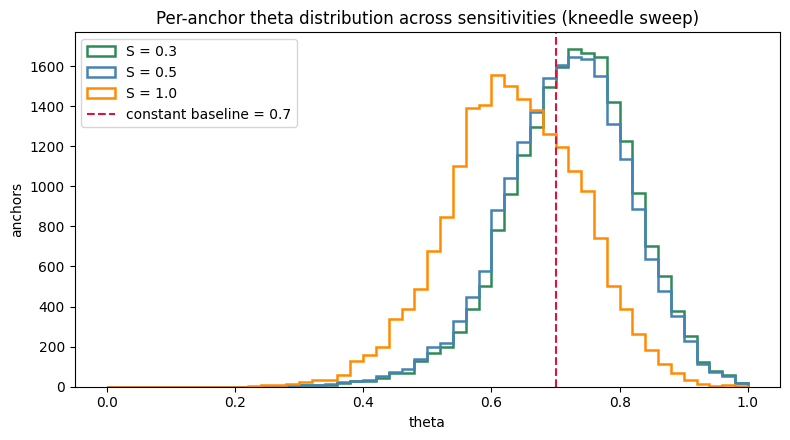

S=0.3: theta mean/median = 0.724/0.729  stricter than 0.7: 12,364 (61.8%)
S=0.5: theta mean/median = 0.717/0.721  stricter than 0.7: 11,718 (58.6%)
S=1.0: theta mean/median = 0.636/0.635  stricter than 0.7: 5,572 (27.9%)


In [10]:
colors = {0.3: "seagreen", 0.5: "steelblue", 1.0: "darkorange"}

fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.linspace(0.0, 1.0, 51)
for v in KNEE_SENSITIVITY_VALUES:
    thetas = np.array([t["theta"] for t in results[v]["thresholds"].values()])
    ax.hist(thetas, bins=bins, histtype="step", linewidth=1.8,
            color=colors.get(v, None), label=f"S = {v:.1f}")
ax.axvline(CONSTANT_THETA_BASELINE, color="crimson", linestyle="--", linewidth=1.5,
           label=f"constant baseline = {CONSTANT_THETA_BASELINE}")
ax.set_title("Per-anchor theta distribution across sensitivities (kneedle sweep)")
ax.set_xlabel("theta"); ax.set_ylabel("anchors")
ax.legend()
plt.tight_layout(); plt.show()

for v in KNEE_SENSITIVITY_VALUES:
    thetas = np.array([t["theta"] for t in results[v]["thresholds"].values()])
    n_stricter = int((thetas > CONSTANT_THETA_BASELINE).sum())
    print(f"S={v:.1f}: theta mean/median = {thetas.mean():.3f}/{np.median(thetas):.3f}  "
          f"stricter than {CONSTANT_THETA_BASELINE}: {n_stricter:,} "
          f"({100 * n_stricter / max(len(thetas), 1):.1f}%)")

## 8. Combined knee_rank distribution — all three values overlaid

Where the detected knees sit along the ranking, per sensitivity (knee-found anchors only). Knees clustered in the tens-to-low-hundreds range are consistent with a genuine boundary; a long tail past several thousand would signal Kneedle locking onto noise instead.

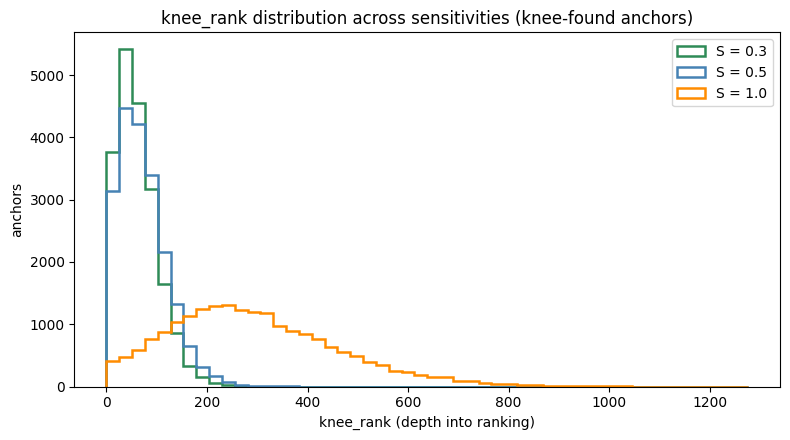

S=0.3: knee_rank min/median/max = 1/56/337  deep (>5000): 0
S=0.5: knee_rank min/median/max = 1/65/392  deep (>5000): 0
S=1.0: knee_rank min/median/max = 1/274/1276  deep (>5000): 0


In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
all_kr = []
for v in KNEE_SENSITIVITY_VALUES:
    kr = [t["knee_rank"] for t in results[v]["thresholds"].values() if t["knee_rank"] is not None]
    all_kr.extend(kr)
if all_kr:
    bins = np.linspace(0, max(all_kr), 51)
    for v in KNEE_SENSITIVITY_VALUES:
        kr = np.array([t["knee_rank"] for t in results[v]["thresholds"].values()
                       if t["knee_rank"] is not None])
        if len(kr):
            ax.hist(kr, bins=bins, histtype="step", linewidth=1.8,
                    color=colors.get(v, None), label=f"S = {v:.1f}")
ax.set_title("knee_rank distribution across sensitivities (knee-found anchors)")
ax.set_xlabel("knee_rank (depth into ranking)"); ax.set_ylabel("anchors")
ax.legend()
plt.tight_layout(); plt.show()

for v in KNEE_SENSITIVITY_VALUES:
    kr = np.array([t["knee_rank"] for t in results[v]["thresholds"].values()
                   if t["knee_rank"] is not None])
    if len(kr):
        n_deep = int((kr > 5000).sum())
        print(f"S={v:.1f}: knee_rank min/median/max = {kr.min()}/{int(np.median(kr))}/{kr.max()}  "
              f"deep (>5000): {n_deep:,}")
    else:
        print(f"S={v:.1f}: (no knees found)")

## 9. Stress-test anchors — theta across all three values

The six stress-test anchors with their adaptive `theta` at each swept sensitivity, next to the fixed 0.70 baseline.

In [12]:
hdr = f"{'anchor':<30}" + "".join(f"{'S=' + format(v, '.1f'):>12}" for v in KNEE_SENSITIVITY_VALUES)
hdr += f"{'fixed':>10}"
print(f"Adaptive theta by sensitivity vs constant baseline ({CONSTANT_THETA_BASELINE})")
print("=" * len(hdr))
print(hdr)
print("-" * len(hdr))
for pid, nm in STRESS_TEST_IDS.items():
    row = f"{nm:<30}"
    for v in KNEE_SENSITIVITY_VALUES:
        t = results[v]["thresholds"].get(pid)
        row += f"{'n/a':>12}" if t is None else f"{t['theta']:>12.3f}"
    row += f"{CONSTANT_THETA_BASELINE:>10.2f}"
    print(row)

Adaptive theta by sensitivity vs constant baseline (0.7)
anchor                               S=0.3       S=0.5       S=1.0     fixed
----------------------------------------------------------------------------
Whole Milk                           0.892       0.892       0.773      0.70
Unsweetened Almond Milk              0.948       0.948       0.723      0.70
Organic Salted Butter                0.936       0.936       0.733      0.70
Vegan Butter                         0.798       0.798       0.798      0.70
Whole Milk Plain Yogurt              0.883       0.883       0.804      0.70
Coconut Yogurt                       0.914       0.914       0.773      0.70


## 10. Rank novelty — grouped by anchor, all three values consecutively

For each stress-test anchor we compute Step 1's own full ranking **once**, then show — for each sensitivity in turn — where that value's surfaced products sit in it. Anything inside Step 1's top-10 is flagged "not new".

In [13]:
surfaced_by_value = {v: {pid: Counter() for pid in STRESS_TEST_IDS}
                     for v in KNEE_SENSITIVITY_VALUES}
for v in KNEE_SENSITIVITY_VALUES:
    for s in results[v]["kept"]:
        a = s["anchor_id"]
        if a in STRESS_TEST_IDS:
            for p in s["sentence"]:
                if p != a:
                    surfaced_by_value[v][a][p] += 1

print("Rank novelty: where do surfaced products sit in Step 1's own ranking?")
print("=" * 78)
for pid, nm in STRESS_TEST_IDS.items():
    print(f"\n{nm} ({pid})")
    if pid not in pid_to_idx:
        print("  — not in catalogue, skipped")
        continue
    sims = embeddings @ embeddings[pid_to_idx[pid]]      # computed ONCE, reused across values
    ranks = np.empty(len(sims), dtype=int)
    ranks[np.argsort(-sims)] = np.arange(len(sims))
    for v in KNEE_SENSITIVITY_VALUES:
        surfaced_here = surfaced_by_value[v][pid]
        print(f"  [S = {v:.1f}]  ({len(surfaced_here)} distinct products surfaced)")
        if not surfaced_here:
            print("     (none)")
        for p, c in surfaced_here.most_common():
            r = int(ranks[pid_to_idx[p]])
            flag = "  <- inside Step 1's top-10, not new" if r <= 10 else ""
            print(f"     {c}x  {name(p):<45} rank={r:>6}  sim={sims[pid_to_idx[p]]:.3f}{flag}")

Rank novelty: where do surfaced products sit in Step 1's own ranking?

Whole Milk (4210)
  [S = 0.3]  (1 distinct products surfaced)
     7x  Organic Whole Milk                            rank=     6  sim=0.892  <- inside Step 1's top-10, not new
  [S = 0.5]  (1 distinct products surfaced)
     7x  Organic Whole Milk                            rank=     6  sim=0.892  <- inside Step 1's top-10, not new
  [S = 1.0]  (24 distinct products surfaced)
     8x  Organic Whole Milk                            rank=     6  sim=0.892  <- inside Step 1's top-10, not new
     5x  Half & Half                                   rank=    57  sim=0.805
     3x  Organic Milk                                  rank=    22  sim=0.834
     3x  Fat Free Milk                                 rank=    29  sim=0.825
     2x  Yogurt, Lowfat, Strawberry                    rank=   137  sim=0.774
     2x  Chocolate Lowfat Milk                         rank=    31  sim=0.823
     2x  Organic Half & Half                  

## 11. Background popularity — grouped by anchor, all three values consecutively

How common each surfaced product is overall, read straight from `product_basket_freq.json`, grouped by anchor first with all three sensitivities shown consecutively.

In [14]:
print("Background popularity: how common is each surfaced product overall?")
print("=" * 78)
for pid, nm in STRESS_TEST_IDS.items():
    anchor_freq = product_basket_count.get(pid, 0)
    anchor_pct = 100 * anchor_freq / total_baskets if total_baskets else 0
    print(f"\n{nm} ({pid}) — anchor appears in "
          f"{anchor_freq:,} / {total_baskets:,} baskets ({anchor_pct:.1f}%)")
    for v in KNEE_SENSITIVITY_VALUES:
        surfaced_here = surfaced_by_value[v][pid]
        print(f"  [S = {v:.1f}]")
        if not surfaced_here:
            print("     (none)")
        for p, c in surfaced_here.most_common(10):
            bg = product_basket_count.get(p, 0)
            bg_pct = 100 * bg / total_baskets if total_baskets else 0
            print(f"     {c}x  {name(p):<40} appears in "
                  f"{bg:>7,} / {total_baskets:,} baskets ({bg_pct:.1f}%)")

Background popularity: how common is each surfaced product overall?

Whole Milk (4210) — anchor appears in 11,103 / 1,000,000 baskets (1.1%)
  [S = 0.3]
     7x  Organic Whole Milk                       appears in  42,879 / 1,000,000 baskets (4.3%)
  [S = 0.5]
     7x  Organic Whole Milk                       appears in  42,879 / 1,000,000 baskets (4.3%)
  [S = 1.0]
     8x  Organic Whole Milk                       appears in  42,879 / 1,000,000 baskets (4.3%)
     5x  Half & Half                              appears in  21,533 / 1,000,000 baskets (2.2%)
     3x  Organic Milk                             appears in   8,660 / 1,000,000 baskets (0.9%)
     3x  Fat Free Milk                            appears in   9,189 / 1,000,000 baskets (0.9%)
     2x  Yogurt, Lowfat, Strawberry               appears in   2,619 / 1,000,000 baskets (0.3%)
     2x  Chocolate Lowfat Milk                    appears in   1,442 / 1,000,000 baskets (0.1%)
     2x  Organic Half & Half                      appea